In [67]:
from sklearn.datasets import make_classification

In [68]:
X,y = make_classification(
    n_samples=500,
    n_features=5,
    n_informative=3,
    n_redundant=1,
    n_classes=2,
    random_state=42
)

In [69]:
import numpy as np

X = np.transpose(X)

In [70]:
dictionary = {
    "f1":X[0],
    "f2":X[1],
    "f3":X[2],
    "f4":X[3],
    "f5":X[4],
    "label":y
}

In [71]:
import pandas as pd


df = pd.DataFrame(dictionary)

In [72]:
df.head()

,f1,f2,f3,f4,f5,label
0,-1.299565,0.608232,-1.518449,1.004770,1.495378,1
1,-0.273844,1.358806,1.194674,1.223679,2.467322,1
2,-2.510600,-2.423153,-0.768365,2.434551,1.227190,0
3,0.374002,-0.794579,-0.093434,-1.252782,-2.123091,0
4,0.378860,1.193772,-0.187534,0.633405,1.692101,1


In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f1      500 non-null    float64
 1   f2      500 non-null    float64
 2   f3      500 non-null    float64
 3   f4      500 non-null    float64
 4   f5      500 non-null    float64
 5   label   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [74]:
df.describe()

,f1,f2,f3,f4,f5,label
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,-0.421863,0.054398,-0.005204,0.379770,0.464957,0.498000
std,1.207009,1.293272,0.979197,1.049075,1.494422,0.500497
min,-3.610431,-3.901277,-2.871283,-2.597305,-3.519458,0.000000
25%,-1.267859,-0.919367,-0.663407,-0.331125,-0.574026,0.000000
50%,-0.482650,-0.075067,0.005652,0.348778,0.561164,0.000000
75%,0.413152,0.989877,0.644043,1.059301,1.412375,1.000000
max,2.875353,3.873269,2.730867,3.851226,4.611751,1.000000


In [75]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(df[["f1","f2","f3","f4","f5"]],df["label"] , train_size=0.8, random_state=42)

In [76]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier


gradient = GradientBoostingClassifier(n_estimators=100 , random_state=42)
ada = AdaBoostClassifier(n_estimators=100 , random_state=42)
xg = XGBClassifier(n_estimators=100 , random_state=42)

In [77]:
gradient.fit(X_train,y_train)


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [78]:
ada.fit(X_train,y_train)


,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [79]:
xg.fit(X_train,y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [80]:
gradient_predict = gradient.predict(X_test)
ada_predict = ada.predict(X_test)
xg_predict = xg.predict(X_test)

In [81]:
from sklearn.metrics import accuracy_score,precision_score,f1_score,recall_score,confusion_matrix

In [82]:
def get_metrics(model, X_test, y_test):

    y_predict = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_predict)
    precision = precision_score(y_test, y_predict)
    recall = recall_score(y_test, y_predict)
    f1 = f1_score(y_test, y_predict)
    cm = confusion_matrix(y_test, y_predict)

    return accuracy,precision,recall,f1,cm

In [83]:
gradient_acc,gradient_precision,gradient_recall,gradient_f1,gradient_cm= get_metrics(gradient, X_test, y_test)
ada_acc,ada_precision,ada_recall,ada_f1 ,ada_cm= get_metrics(ada, X_test, y_test)
xg_acc,xg_precision,xg_recall,xg_f1 ,xg_cm= get_metrics(xg, X_test, y_test)


In [84]:
comparison = pd.DataFrame({
    "Model":["GradientBoosting","AdaBoosting","XGBoosting"],
    "Accuracy":[gradient_acc,ada_acc,xg_acc],
    "Precision":[gradient_precision,ada_precision,xg_precision],
    "Recall":[gradient_recall,ada_recall,xg_recall],
    "F1":[gradient_f1,ada_f1,xg_f1]
})

In [85]:
print(comparison)

              Model  Accuracy  Precision    Recall        F1
0  GradientBoosting      0.92   0.925000  0.880952  0.902439
1       AdaBoosting      0.89   0.897436  0.833333  0.864198
2        XGBoosting      0.91   0.902439  0.880952  0.891566


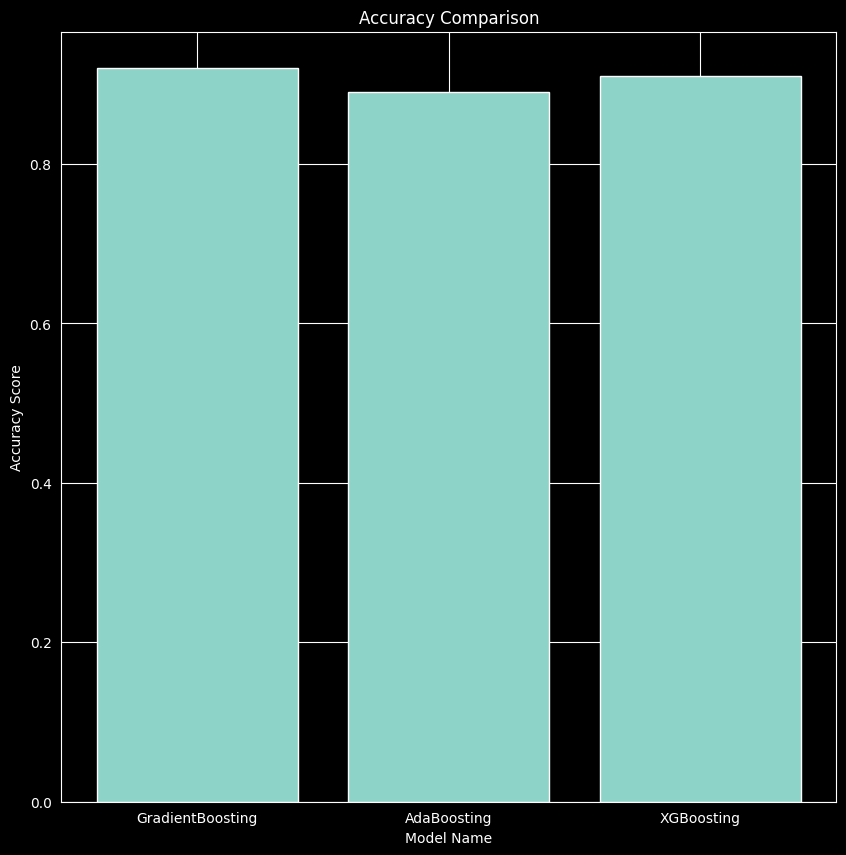

In [90]:
# Accuracy compare bar chart

import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.bar(comparison["Model"] , [gradient_acc,ada_acc,xg_acc])
plt.xlabel("Model Name")
plt.ylabel("Accuracy Score")
plt.title("Accuracy Comparison")
plt.show()

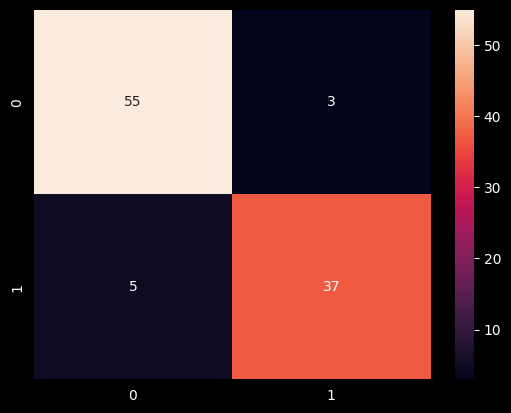

In [87]:
import seaborn as sns

sns.heatmap(gradient_cm , annot=True)

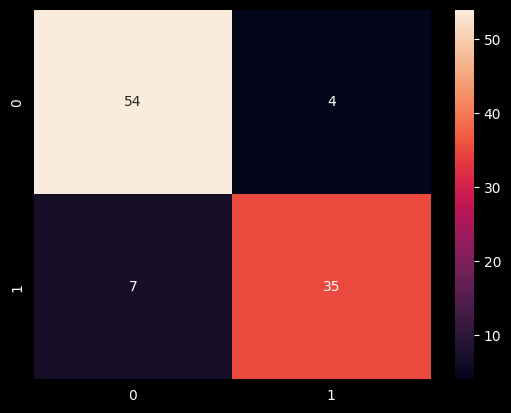

In [88]:
sns.heatmap(ada_cm , annot=True)

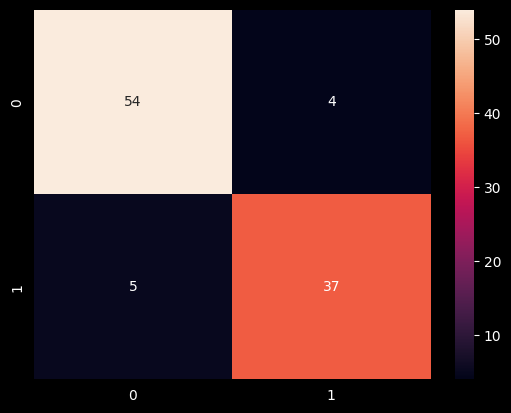

In [89]:
sns.heatmap(xg_cm , annot=True)